In [1]:
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from srm import catalog
from srm.config import _icechunk_storage_for_path
from srm.qa_flags import (
    calculate_thresholds,
    flag_global_exceedances,
    flag_outliers,
    flag_rsds_above_max,
    get_data,
    parse_tag,
    plot_flags,
    run_flag_loop,
    write_individual_flags,
)

In [2]:
from srm.downscaling_utils import interpolate_coarse_to_fine_grid, interpolate_fine_to_coarse_grid
from srm.qaqc import calculate_distortion_flags, sign_flip_mask

# A. Define what data arrays exist to traverse

In [3]:
# --- Run parameters --------------------------------------------------------
# This regional South-Africa-box run covers three GCMs, each written to its own icechunk store
# (same bucket/branch, named by GCM the same way srm.cache.ArtifactCache names pipeline output
# stores). Looping over GCMS -- rather than hardcoding one, as this notebook used to -- is what
# lets every leaf be compared against ITS OWN GCM's catalog and lineage instead of silently
# reusing whichever GCM happened to be hardcoded.


VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds"]  # , "hurs"]

In [4]:
GCMS = ["CESM2-WACCM"]

# BRANCH = "full-regional-run-issue-534"
# ROOT_DIR = "s3://carbonplan-scratch/srm/output/qa/"
# STORE_SUBSET_BOUNDS = (-38.0, -19.0, 13.0, 36.0)
# STORE_SUBSET_ID = ArtifactCache._get_subset_id(STORE_SUBSET_BOUNDS)

BRANCH = "v0.13.0"
ROOT_DIR = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/"
STORE_SUBSET_ID = "global"

In [5]:
def store_uri(gcm: str, root_dir: str = ROOT_DIR) -> str:
    return f"{root_dir}{gcm}-ERA5-{STORE_SUBSET_ID}.icechunk"

In [6]:
trees: dict[str, xr.DataTree] = {}
open_errors: dict[str, str] = {}

for gcm in GCMS:
    try:
        repo = icechunk.Repository.open(_icechunk_storage_for_path(store_uri(gcm)))
        session = repo.readonly_session(BRANCH) if BRANCH else repo.readonly_session()
        trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks={})
    except Exception as exc:  # noqa: BLE001  # report every failure, do not stop at the first
        open_errors[gcm] = f"{type(exc).__name__}: {exc}"

for gcm, err in open_errors.items():
    print(f"FAILED to open {gcm}: {err}")

# GCMs whose store actually opened. A GCM whose run is still in flight is skipped here rather
# than failing the whole notebook, so this check can be run against a partially-landed run.
OPEN_GCMS = tuple(gcm for gcm in GCMS if gcm in trees)
print(f"opened {len(OPEN_GCMS)}/{len(GCMS)} stores on branch {BRANCH!r}: {', '.join(OPEN_GCMS)}")

trees[OPEN_GCMS[0]]

opened 1/1 stores on branch 'v0.13.0': CESM2-WACCM


<xarray.DataTree>
Group: /
├── Group: /debiased_coarse
│   ├── Group: /debiased_coarse/g6_1p5k
│   │   ├── Group: /debiased_coarse/g6_1p5k/dtr
│   │   │   ├── Group: /debiased_coarse/g6_1p5k/dtr/002
│   │   │   │       Dimensions:  (time: 18263, lat: 192, lon: 288)
│   │   │   │       Coordinates:
│   │   │   │         * time     (time) datetime64[ns] 146kB 2035-01-01 2035-01-02 ... 2084-12-31
│   │   │   │         * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
│   │   │   │         * lon      (lon) float64 2kB -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8
│   │   │   │       Data variables:
│   │   │   │           dtr      (time, lat, lon) float32 4GB dask.array<chunksize=(8000, 8, 16), meta=np.ndarray>
│   │   │   │       Attributes: (12/17)
│   │   │   │           Conventions:                                 CF-1.8
│   │   │   │           institution:                                 CarbonPlan
│   │   │   │           history:                                     2026-08-07T19:27:13Z: BCSD d...
│   │   │   │           srm_downscaling:version:                     0.13.0
│   │   │   │           srm_downscaling:gcm:                         CESM2-WACCM
│   │   │   │           srm_downscaling:scenario:                    G6-1.5K
│   │   │   │           ...                                          ...
│   │   │   │           srm_downscaling:bias_correction_method:      nonparametric_hybrid_2sided
│   │   │   │           srm_downscaling:downscaling_method:          multiplicative
│   │   │   │           srm_downscaling:train_period:                1978-2014
│   │   │   │           srm_downscaling:config_hash:                 dd796b11cdf7
│   │   │   │           srm_downscaling:config_json:                 {"gcm":"CESM2-WACCM","variab...
│   │   │   │           srm_downscaling:creation_date:               2026-08-07
│   │   │   └── Group: /debiased_coarse/g6_1p5k/dtr/003
│   │   │           Dimensions:  (time: 18263, lat: 192, lon: 288)
│   │   │           Coordinates:
│   │   │             * time     (time) datetime64[ns] 146kB 2035-01-01 2035-01-02 ... 2084-12-31
│   │   │             * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
│   │   │             * lon      (lon) float64 2kB -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8
│   │   │           Data variables:
│   │   │               dtr      (time, lat, lon) float32 4GB dask.array<chunksize=(8000, 8, 16), meta=np.ndarray>
│   │   │           Attributes: (12/17)
│   │   │               Conventions:                                 CF-1.8
│   │   │               institution:                                 CarbonPlan
│   │   │               history:                                     2026-08-07T19:27:44Z: BCSD d...
│   │   │               srm_downscaling:version:                     0.13.0
│   │   │               srm_downscaling:gcm:                         CESM2-WACCM
│   │   │               srm_downscaling:scenario:                    G6-1.5K
│   │   │               ...                                          ...
│   │   │               srm_downscaling:bias_correction_method:      nonparametric_hybrid_2sided
│   │   │               srm_downscaling:downscaling_method:          multiplicative
│   │   │               srm_downscaling:train_period:                1978-2014
│   │   │               srm_downscaling:config_hash:                 6d3c5e6ce6b3
│   │   │               srm_downscaling:config_json:                 {"gcm":"CESM2-WACCM","variab...
│   │   │               srm_downscaling:creation_date:               2026-08-07
│   │   ├── Group: /debiased_coarse/g6_1p5k/tasmin
│   │   │   ├── Group: /debiased_coarse/g6_1p5k/tasmin/002
│   │   │   │       Dimensions:  (time: 18263, lat: 192, lon: 288)
│   │   │   │       Coordinates:
│   │   │   │         * time     (time) datetime64[ns] 146kB 2035-01-01 2035-01-02 ... 2084-12-31
│   │   │   │         * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.

In [7]:
gcms, scenarios, variables, ensembles = [], [], [], []

for gcm in OPEN_GCMS:
    tree = trees[gcm]
    for scenario_name, scenario_node in tree.children.items():
        for var_name, var_node in scenario_node.children.items():
            for ens_name, ens_node in var_node.children.items():
                gcms.append(gcm)
                scenarios.append(scenario_name)
                variables.append(var_name)
                ensembles.append(ens_name)

print(f"{len(gcms)} leaves across {len(OPEN_GCMS)} GCMs")

71 leaves across 1 GCMs


In [8]:
keep_idx = [i for i, s in enumerate(scenarios) if s != "debiased_coarse"]
gcms = [gcms[i] for i in keep_idx]
scenarios = [scenarios[i] for i in keep_idx]
variables = [variables[i] for i in keep_idx]
ensembles = [ensembles[i] for i in keep_idx]

keep_idx = [i for i, v in enumerate(variables) if v != "dtr"]
gcms = [gcms[i] for i in keep_idx]
scenarios = [scenarios[i] for i in keep_idx]
variables = [variables[i] for i in keep_idx]
ensembles = [ensembles[i] for i in keep_idx]

keep_idx = [i for i, v in enumerate(variables) if v != "hurs"]
gcms = [gcms[i] for i in keep_idx]
scenarios = [scenarios[i] for i in keep_idx]
variables = [variables[i] for i in keep_idx]
ensembles = [ensembles[i] for i in keep_idx]

In [9]:
tags = []
for i, gcm in enumerate(gcms):
    var = variables[i]
    scenario = scenarios[i]
    ens = ensembles[i]
    tag = f"{gcm}_{var}_{scenario}_{ens}"
    tags.append(tag)

In [10]:
gcms_np = np.array(gcms)
scenarios_np = np.array(scenarios)
variables_np = np.array(variables)
ensembles_np = np.array(ensembles)
tags_np = np.array(tags)

In [11]:
PLOT_FLAG_MAPS = True
FLAG_OUTPUT_DIR = "s3://carbonplan-scratch/srm/qaqc/flags/" + STORE_SUBSET_ID + "/"

## Set up cluster

In [37]:
import os

import coiled
from frisky import hijack

from srm.config import (
    ClusterConfig,
)

os.environ["FRISKY_SUMMARY"] = "off"

In [38]:
cfg = ClusterConfig(
    n_workers=20,
    worker_vm_types=["r8g.2xlarge"],  # 8 vCPU, 64 GB
    scheduler_vm_types=["r8g.2xlarge"],
    spot_policy="spot_with_fallback",
)

cluster = coiled.Cluster(
    name="srm-qaqc-flag-generation",
    region=cfg.region,
    n_workers=cfg.n_workers,
    worker_vm_types=cfg.worker_vm_types,
    scheduler_vm_types=cfg.scheduler_vm_types,
    spot_policy=cfg.spot_policy,
    use_best_zone=True,
    tags=cfg.tags,
    worker_disk_size=250,
)

client = hijack(cluster.get_client())

╭─────────────────────────────── Coiled Cluster ───────────────────────────────╮
│                   ]8;id=11047240;https://cloud.coiled.io/clusters/1942375\https://cloud.coiled.io/clusters/1942375]8;;\                   │
╰──────────────────────────────────────────────────────────────────────────────╯
╭────────────── Overview ──────────────╮╭─────────── Configuration ────────────╮
│                                      ││                                      │
│ Name: srm-qaqc-flag-generation       ││ Region: us-west-2                    │
│                                      ││                                      │
│ Scheduler Status: started            ││ Scheduler: r8g.2xlarge               │
│                                      ││                                      │
│ Dashboard:                           ││ Workers:   r8g.2xlarge (20)          │
│ ]8;id=11047243;https://cluster-gqzoi.dask.host?token=BE1xyXY1FRXrUalR\https://cluster-gqzoi.dask.host?toke]8;;\ ││                                      │
│ ]8;id=11047243;https://cluster-gqzoi.dask.host?token=BE1xyXY1FRXrUalR\n=BE1xyXY1FRXrUalR]8;;\                   ││ Workers Requested: 20                │
│                                      ││                                      │
╰──────────────────────────────────────╯╰──────────────────────────────────────╯
╭───────────────────────── (2026/08/20 23:11:59 UTC) ──────────────────────────╮
│                                                                              │
│          Most of your workers have arrived. Cluster ready for use.           │
│                                                                              │
│                                                                              │
╰──────────────────────────────────────────────────────────────────────────────╯

# B. Generate individual time-varying QA flags

## 1. Outliers based on observations

### 1a. Calculate outlier bounds

In [15]:
store = "s3://carbonplan-scratch/srm/qaqc/doy_obs_thresholds_global.zarr"
combined = xr.open_zarr(store)

In [16]:
def _split(ds, suffix):
    names = [v for v in ds.data_vars if v.endswith(suffix)]
    return ds[names].rename({v: v[: -len(suffix)] for v in names})


obs_max = _split(combined, "_max")
obs_min = _split(combined, "_min")
obs_max_std = _split(combined, "_max_std")
obs_min_std = _split(combined, "_min_std")

In [17]:
[outlier_thresh_low, outlier_thresh_high] = calculate_thresholds(
    obs_max, obs_min, obs_max_std, obs_min_std
)

### 1b. Traverse dataset and save flags

In [18]:
outlier_thresh_low_annual = outlier_thresh_low.min(dim="dayofyear")
outlier_thresh_high_annual = outlier_thresh_high.max(dim="dayofyear")

31
CESM2-WACCM_pr_g6_1p5k_002


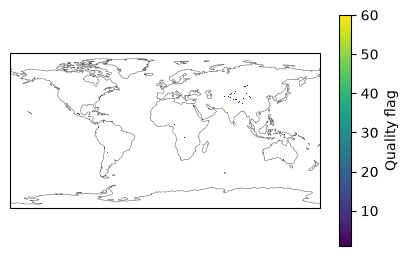

CESM2-WACCM_pr_g6_1p5k_003


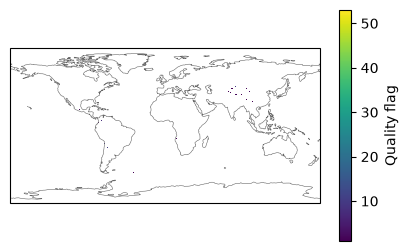

CESM2-WACCM_rsds_g6_1p5k_002


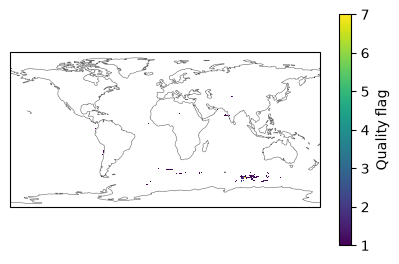

CESM2-WACCM_rsds_g6_1p5k_003


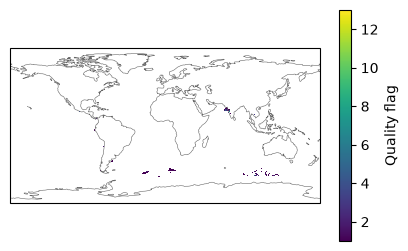

CESM2-WACCM_tas_g6_1p5k_002


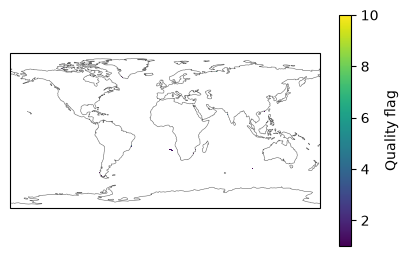

CESM2-WACCM_tas_g6_1p5k_003


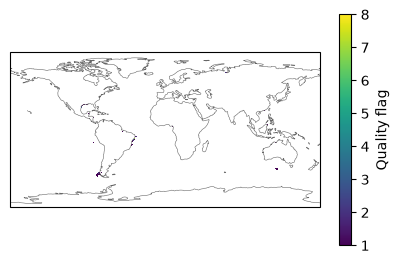

CESM2-WACCM_tasmax_g6_1p5k_002


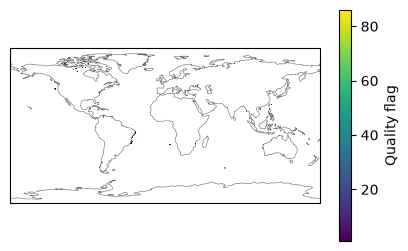

CESM2-WACCM_tasmax_g6_1p5k_003


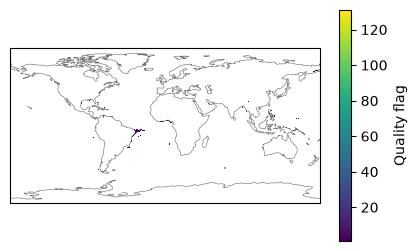

CESM2-WACCM_tasmin_g6_1p5k_002


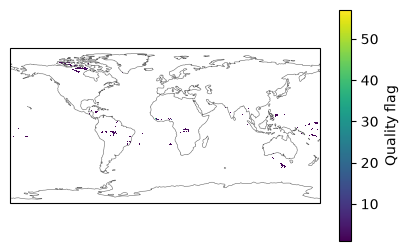

CESM2-WACCM_tasmin_g6_1p5k_003


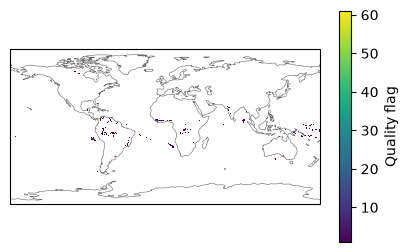

CESM2-WACCM_pr_g6_1p5k_end_002


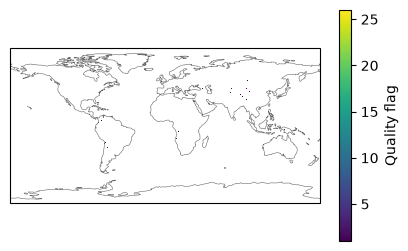

CESM2-WACCM_rsds_g6_1p5k_end_002


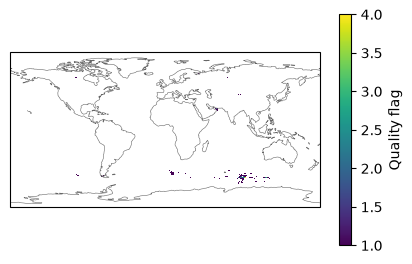

CESM2-WACCM_tas_g6_1p5k_end_002


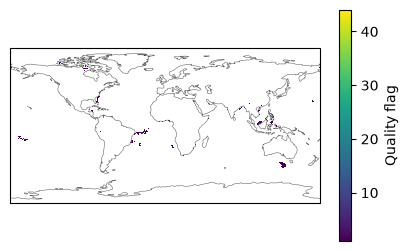

CESM2-WACCM_tasmax_g6_1p5k_end_002


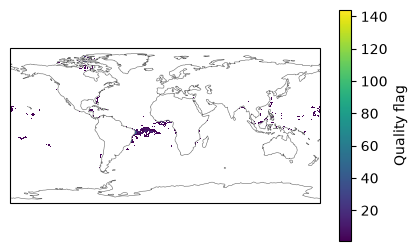

CESM2-WACCM_tasmin_g6_1p5k_end_002


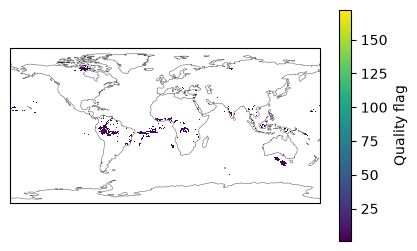

CESM2-WACCM_pr_historical_r2i1p1f1


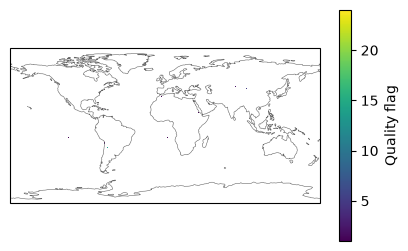

CESM2-WACCM_pr_historical_r3i1p1f1


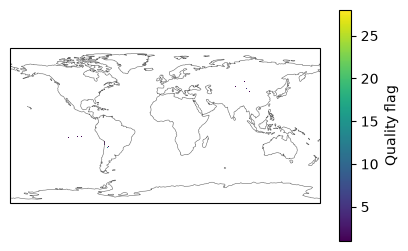

CESM2-WACCM_rsds_historical_r2i1p1f1
CESM2-WACCM_rsds_historical_r3i1p1f1
CESM2-WACCM_tas_historical_r2i1p1f1
CESM2-WACCM_tas_historical_r3i1p1f1
CESM2-WACCM_tasmin_historical_001


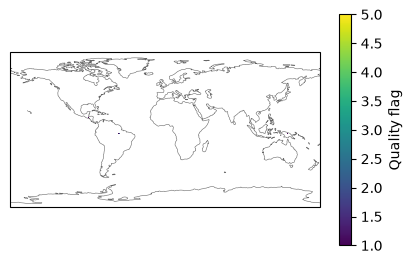

CESM2-WACCM_tasmax_historical_001
CESM2-WACCM_tasmax_ssp245_008


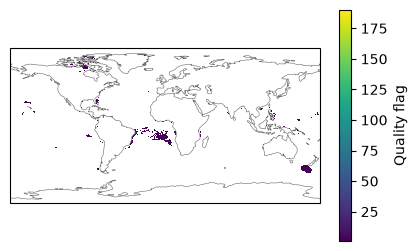

CESM2-WACCM_pr_ssp245_003


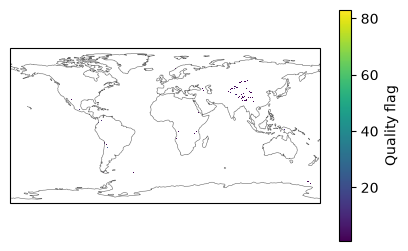

CESM2-WACCM_pr_ssp245_008


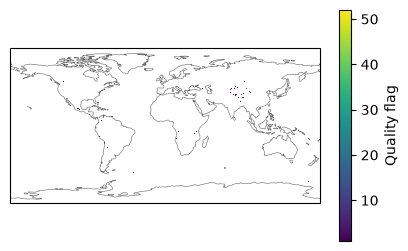

CESM2-WACCM_rsds_ssp245_003


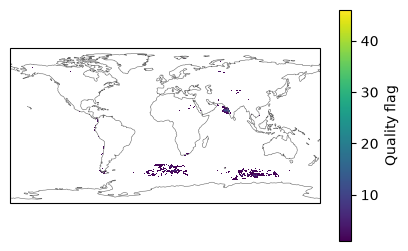

CESM2-WACCM_rsds_ssp245_008


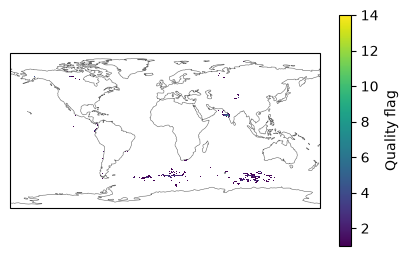

CESM2-WACCM_tas_ssp245_003


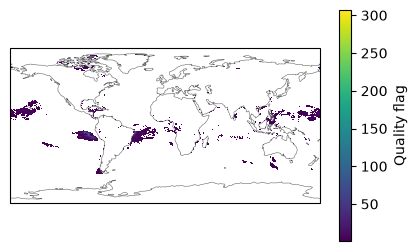

CESM2-WACCM_tas_ssp245_008


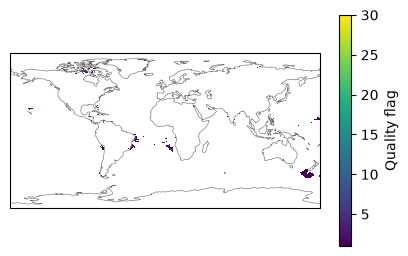

CESM2-WACCM_tasmin_ssp245_008


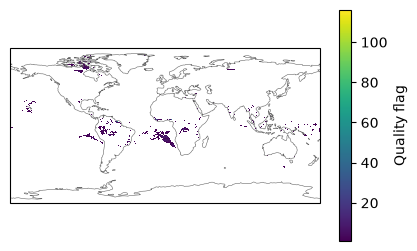

In [19]:
run_flag_loop(
    tags=tags,
    trees=trees,
    flag_name="annual_outlier_flag",
    compute_flag=lambda da, var: flag_outliers(
        da=da,
        outlier_thresh_low=outlier_thresh_low_annual[var],
        outlier_thresh_high=outlier_thresh_high_annual[var],
        timescale="annual",
    ),
    flag_dir=FLAG_OUTPUT_DIR,
    write_mode="w",
)

## 2. rsds-specific latitude check

In [20]:
def load_rsds_lims(
    key: str = "zonal_doy_max_rsds",
    fpath: str = "s3://carbonplan-scratch/srm/qaqc/zonal_doy_max_rsds.zarr",
) -> xr.DataArray:
    return xr.open_zarr(fpath, group=key)["data"].load()

In [21]:
zonal_doy_max_rsds = load_rsds_lims()

31
CESM2-WACCM_rsds_g6_1p5k_002


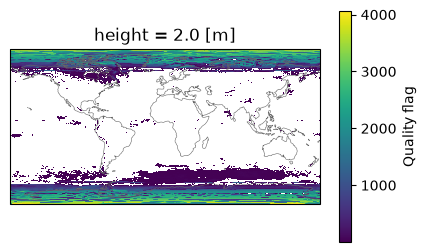

CESM2-WACCM_rsds_g6_1p5k_003


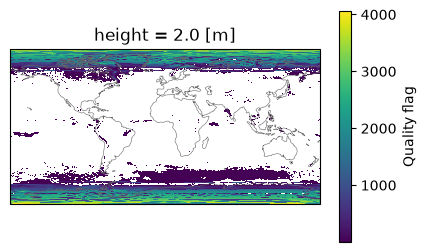

CESM2-WACCM_rsds_g6_1p5k_end_002


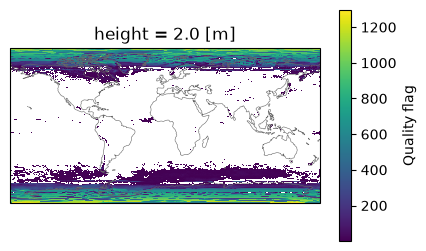

CESM2-WACCM_rsds_historical_r2i1p1f1


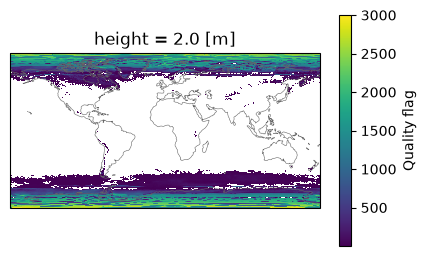

CESM2-WACCM_rsds_historical_r3i1p1f1


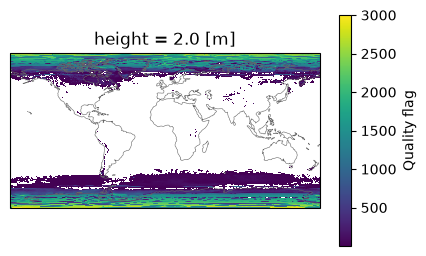

CESM2-WACCM_rsds_ssp245_003


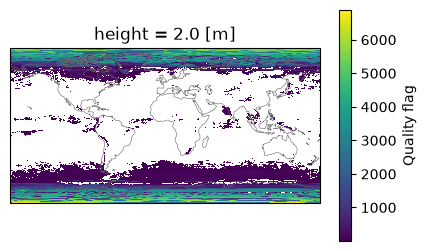

CESM2-WACCM_rsds_ssp245_008


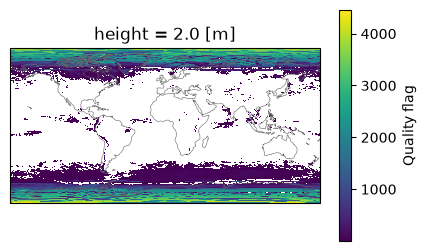

In [22]:
run_flag_loop(
    tags=tags,
    trees=trees,
    flag_name="rsds_max_exceeded",
    compute_flag=lambda da, var: flag_rsds_above_max(da=da, zonal_doy_max_rsds=zonal_doy_max_rsds),
    var_filter="rsds",
    flag_dir=FLAG_OUTPUT_DIR,
)

## 3. global exceedances

31
CESM2-WACCM_pr_g6_1p5k_002
CESM2-WACCM_pr_g6_1p5k_003
CESM2-WACCM_rsds_g6_1p5k_002


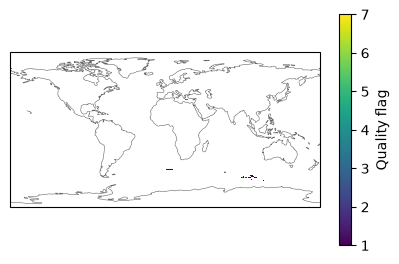

CESM2-WACCM_rsds_g6_1p5k_003


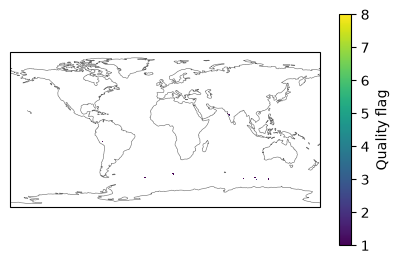

CESM2-WACCM_tas_g6_1p5k_002
CESM2-WACCM_tas_g6_1p5k_003
CESM2-WACCM_tasmax_g6_1p5k_002
CESM2-WACCM_tasmax_g6_1p5k_003
CESM2-WACCM_tasmin_g6_1p5k_002
CESM2-WACCM_tasmin_g6_1p5k_003
CESM2-WACCM_pr_g6_1p5k_end_002
CESM2-WACCM_rsds_g6_1p5k_end_002


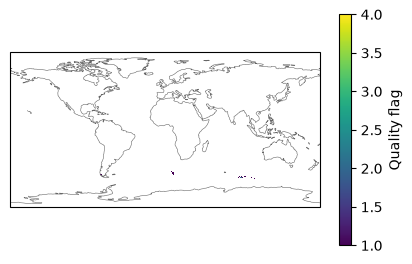

CESM2-WACCM_tas_g6_1p5k_end_002
CESM2-WACCM_tasmax_g6_1p5k_end_002
CESM2-WACCM_tasmin_g6_1p5k_end_002
CESM2-WACCM_pr_historical_r2i1p1f1
CESM2-WACCM_pr_historical_r3i1p1f1
CESM2-WACCM_rsds_historical_r2i1p1f1


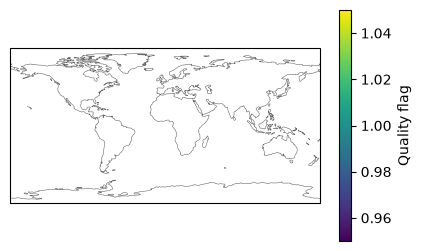

CESM2-WACCM_rsds_historical_r3i1p1f1


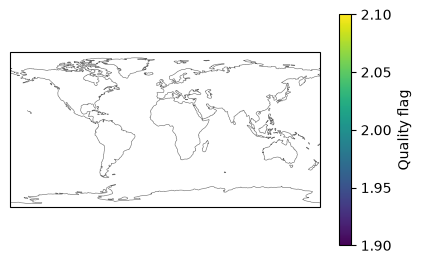

CESM2-WACCM_tas_historical_r2i1p1f1
CESM2-WACCM_tas_historical_r3i1p1f1
CESM2-WACCM_tasmin_historical_001
CESM2-WACCM_tasmax_historical_001
CESM2-WACCM_tasmax_ssp245_008
CESM2-WACCM_pr_ssp245_003
CESM2-WACCM_pr_ssp245_008
CESM2-WACCM_rsds_ssp245_003


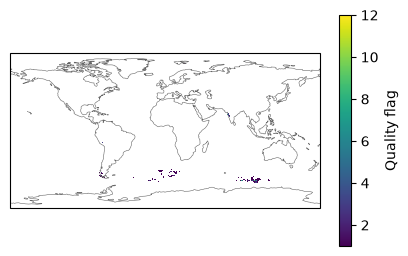

CESM2-WACCM_rsds_ssp245_008


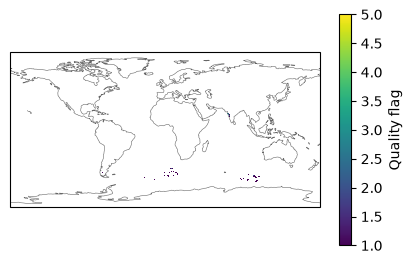

CESM2-WACCM_tas_ssp245_003
CESM2-WACCM_tas_ssp245_008
CESM2-WACCM_tasmin_ssp245_008


In [23]:
run_flag_loop(
    tags=tags,
    trees=trees,
    flag_name="outside_global_plausible_range",
    compute_flag=lambda da, var: flag_global_exceedances(da=da, var=var),
    flag_dir=FLAG_OUTPUT_DIR,
)

## 4. temperature inconsistencies

In [24]:
from srm.qa_flags import flag_tasmax_tas_inconsistency, flag_tasmin_tas_inconsistency

31
CESM2-WACCM_tas_g6_1p5k_002


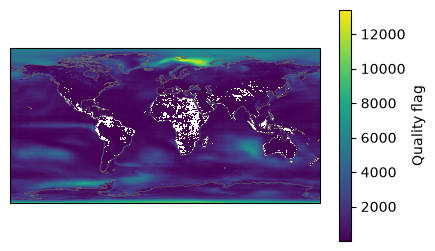

CESM2-WACCM_tas_g6_1p5k_003


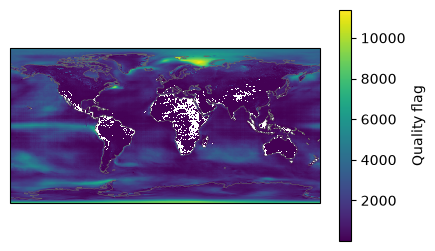

CESM2-WACCM_tas_g6_1p5k_end_002


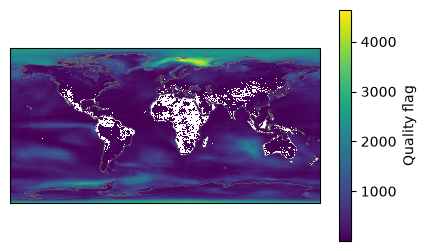

CESM2-WACCM_tas_ssp245_008


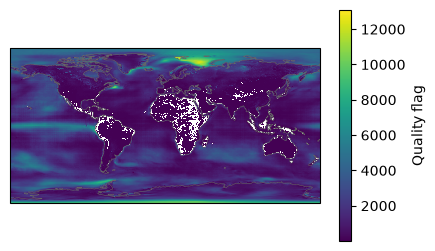

In [25]:
# This could be modified to fit within the run_flag_loop structure

var_filter = "tas"
plot = True

print(len(tags))
for tag in tags:
    gcm, var, scenario, ens = parse_tag(tag)
    if var_filter is not None and var != var_filter:
        continue

    tag_tasmin = f"{gcm}_tasmin_{scenario}_{ens}"
    tag_tasmax = f"{gcm}_tasmax_{scenario}_{ens}"
    if (tag_tasmin in tags) and (tag_tasmax in tags):
        print(tag)

        tas = get_data(tag=tag, trees=trees)
        tasmin = get_data(tag=tag_tasmin, trees=trees)
        tasmax = get_data(tag=tag_tasmax, trees=trees)

        flag_tas_tasmax = flag_tasmax_tas_inconsistency(tas, tasmax)
        flag_tas_tasmin = flag_tasmin_tas_inconsistency(tas, tasmin)

        flag_tas = (flag_tas_tasmax + flag_tas_tasmin) > 0
        flag_tasmin = flag_tas_tasmin
        flag_tasmax = flag_tas_tasmax

        write_individual_flags(
            flag_data=flag_tas,
            flag_name="temperature_inconsistency",
            gcm=gcm,
            var="tas",
            scenario=scenario,
            ens=ens,
            write_mode="a",
            flag_dir=FLAG_OUTPUT_DIR,
        )

        write_individual_flags(
            flag_data=flag_tasmax,
            flag_name="temperature_inconsistency",
            gcm=gcm,
            var="tasmax",
            scenario=scenario,
            ens=ens,
            write_mode="a",
            flag_dir=FLAG_OUTPUT_DIR,
        )

        write_individual_flags(
            flag_data=flag_tasmin,
            flag_name="temperature_inconsistency",
            gcm=gcm,
            var="tasmin",
            scenario=scenario,
            ens=ens,
            write_mode="a",
            flag_dir=FLAG_OUTPUT_DIR,
        )

        if plot:
            plot_flags(flags=flag_tas, time_varying=True, separate_low_high=False)
            plt.show()
            plt.close()

# C. Generate flags that are constant over time

In [39]:
from srm.qa_flags import TREND_VARIABLE_SETTINGS as VARIABLE_SETTINGS

In [40]:
def calculate_ensemble_mean_deltas(
    variable,
    tags_scenario1,
    tags_scenario2,
    gcm,
    scenario1,
    scenario2,
    scenario1_time_slice,
    scenario2_time_slice,
):
    # Construct data arrays including all relevant ensemble members
    das_scenario1 = []
    ens_scenario1 = []
    for tag in tags_scenario1:
        da = get_data(tag=tag, trees=trees)
        thisgcm, thisvar, thisscenario, thisens = parse_tag(tag)
        das_scenario1.append(da)
        ens_scenario1.append(thisens)

    var_scenario1 = xr.concat(das_scenario1, dim=pd.Index(ens_scenario1, name="ensemble_member"))

    das_scenario2 = []
    ens_scenario2 = []
    for tag in tags_scenario2:
        da = get_data(tag=tag, trees=trees)
        thisgcm, thisvar, thisscenario, thisens = parse_tag(tag)
        das_scenario2.append(da)
        ens_scenario2.append(thisens)

    var_scenario2 = xr.concat(das_scenario2, dim=pd.Index(ens_scenario2, name="ensemble_member"))

    # Take ensemble mean across comparison time periods
    ens_mean_var_scenario1 = var_scenario1.sel(time=scenario1_time_slice).mean(
        dim=["time", "ensemble_member"]
    )
    ens_mean_var_scenario2 = var_scenario2.sel(time=scenario2_time_slice).mean(
        dim=["time", "ensemble_member"]
    )

    # Take ensemble mean across comparison time periods in raw data
    raw_ds = catalog.get(gcm).to_xarray()
    raw_scenario1_mean = (
        raw_ds[scenario1][variable]
        .sel(time=scenario1_time_slice, ensemble_member=ens_scenario1)
        .mean(dim=["time", "ensemble_member"])
    )
    raw_scenario2_mean = (
        raw_ds[scenario2][variable]
        .sel(time=scenario2_time_slice, ensemble_member=ens_scenario2)
        .mean(dim=["time", "ensemble_member"])
    )

    # Coarsen the downscaled ensemble means
    ens_mean_var_scenario1_coarsened = interpolate_fine_to_coarse_grid(
        da_fine_to_coarsen=ens_mean_var_scenario1, da_coarse_grid=raw_scenario1_mean
    ).compute()
    ens_mean_var_scenario2_coarsened = interpolate_fine_to_coarse_grid(
        da_fine_to_coarsen=ens_mean_var_scenario2, da_coarse_grid=raw_scenario1_mean
    ).compute()

    # Calculate scenario comparison (annual mean) in downscaled and raw
    delta_raw = raw_scenario2_mean - raw_scenario1_mean
    delta_raw_pct = delta_raw * 100 / raw_scenario1_mean

    delta_ds_coarse = ens_mean_var_scenario2_coarsened - ens_mean_var_scenario1_coarsened
    delta_ds_coarse_pct = delta_ds_coarse * 100 / ens_mean_var_scenario1_coarsened

    delta_ds = ens_mean_var_scenario2 - ens_mean_var_scenario1

    return delta_raw, delta_raw_pct, delta_ds_coarse, delta_ds_coarse_pct, delta_ds

In [41]:
scenario_comparisons = {
    "g6_1p5k_ssp245": {
        "scenario1": "ssp245",
        "scenario1_time_slice": slice("2065-01-01", "2084-12-31"),
        "scenario2": "g6_1p5k",
        "scenario2_time_slice": slice("2065-01-01", "2084-12-31"),
    },
    "ssp245_hist": {
        "scenario1": "historical",
        "scenario1_time_slice": slice("1978-01-01", "2014-12-31"),
        "scenario2": "ssp245",
        "scenario2_time_slice": slice("2065-01-01", "2084-12-31"),
    },
    "g6_1p5k_hist": {
        "scenario1": "historical",
        "scenario1_time_slice": slice("1978-01-01", "2014-12-31"),
        "scenario2": "g6_1p5k",
        "scenario2_time_slice": slice("2065-01-01", "2084-12-31"),
    },
    "g6_1p5k_end_g6_1p5k": {
        "scenario1": "g6_1p5k",
        "scenario1_time_slice": slice("2065-01-01", "2084-12-31"),
        "scenario2": "g6_1p5k_end",
        "scenario2_time_slice": slice("2085-01-01", "2099-12-31"),
    },
}

g6_1p5k_ssp245
tas


/tmp/ipykernel_51629/3292307420.py:20: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario1 = xr.concat(das_scenario1, dim=pd.Index(ens_scenario1, name="ensemble_member"))
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 90
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env

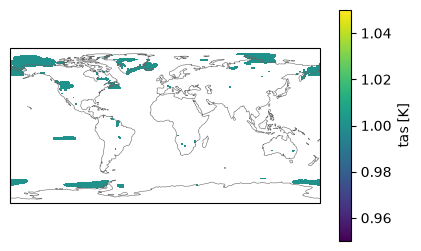

CESM2-WACCM_tas_ssp245_003
CESM2-WACCM_tas_ssp245_008
CESM2-WACCM_tas_g6_1p5k_002
CESM2-WACCM_tas_g6_1p5k_003
tasmax


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

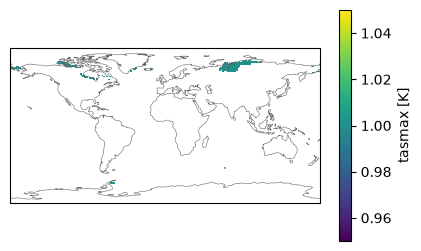

CESM2-WACCM_tasmax_ssp245_008
CESM2-WACCM_tasmax_g6_1p5k_002
CESM2-WACCM_tasmax_g6_1p5k_003
tasmin


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

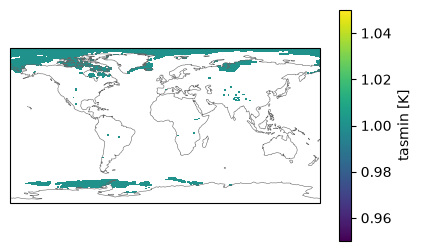

CESM2-WACCM_tasmin_ssp245_008
CESM2-WACCM_tasmin_g6_1p5k_002
CESM2-WACCM_tasmin_g6_1p5k_003
pr


/tmp/ipykernel_51629/3292307420.py:20: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario1 = xr.concat(das_scenario1, dim=pd.Index(ens_scenario1, name="ensemble_member"))
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 90
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env

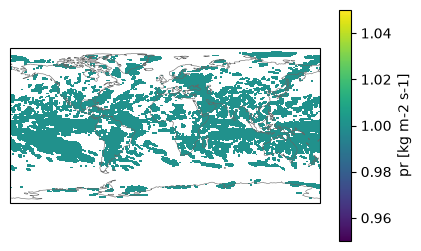

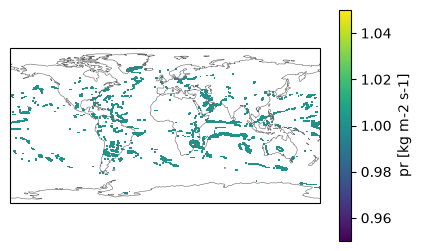

CESM2-WACCM_pr_ssp245_003
CESM2-WACCM_pr_ssp245_008
CESM2-WACCM_pr_g6_1p5k_002
CESM2-WACCM_pr_g6_1p5k_003
rsds


/tmp/ipykernel_51629/3292307420.py:20: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario1 = xr.concat(das_scenario1, dim=pd.Index(ens_scenario1, name="ensemble_member"))
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 90
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env

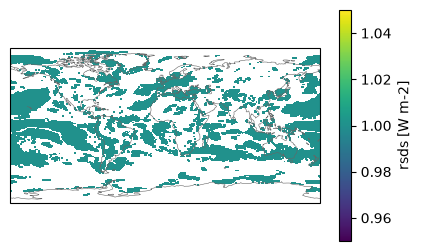

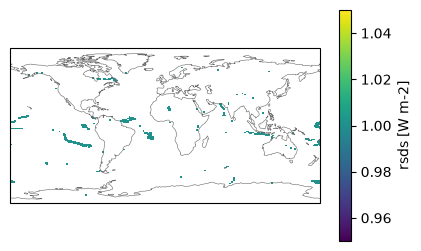

CESM2-WACCM_rsds_ssp245_003
CESM2-WACCM_rsds_ssp245_008
CESM2-WACCM_rsds_g6_1p5k_002
CESM2-WACCM_rsds_g6_1p5k_003
ssp245_hist
tas


/tmp/ipykernel_51629/3292307420.py:30: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario2 = xr.concat(das_scenario2, dim=pd.Index(ens_scenario2, name="ensemble_member"))
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 90
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env

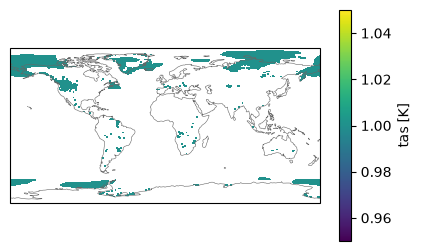

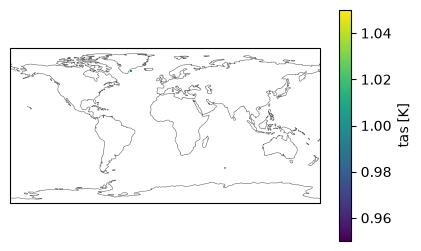

CESM2-WACCM_tas_historical_r2i1p1f1
CESM2-WACCM_tas_historical_r3i1p1f1
CESM2-WACCM_tas_ssp245_003
CESM2-WACCM_tas_ssp245_008
tasmax


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

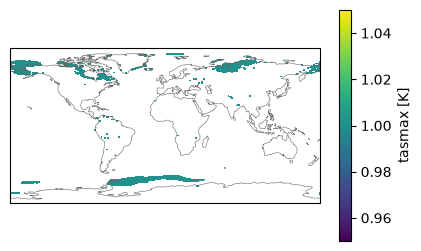

CESM2-WACCM_tasmax_historical_001
CESM2-WACCM_tasmax_ssp245_008
tasmin


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

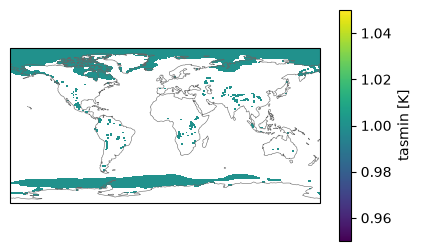

CESM2-WACCM_tasmin_historical_001
CESM2-WACCM_tasmin_ssp245_008
pr


/tmp/ipykernel_51629/3292307420.py:30: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario2 = xr.concat(das_scenario2, dim=pd.Index(ens_scenario2, name="ensemble_member"))
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 90
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env

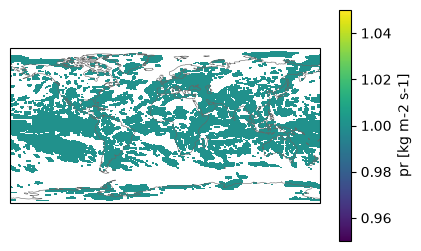

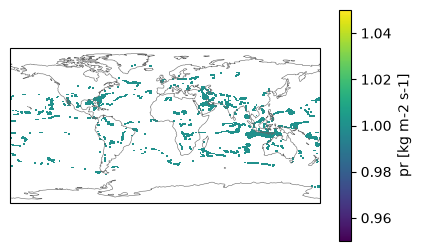

CESM2-WACCM_pr_historical_r2i1p1f1
CESM2-WACCM_pr_historical_r3i1p1f1
CESM2-WACCM_pr_ssp245_003
CESM2-WACCM_pr_ssp245_008
rsds


/tmp/ipykernel_51629/3292307420.py:30: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario2 = xr.concat(das_scenario2, dim=pd.Index(ens_scenario2, name="ensemble_member"))
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 90
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env

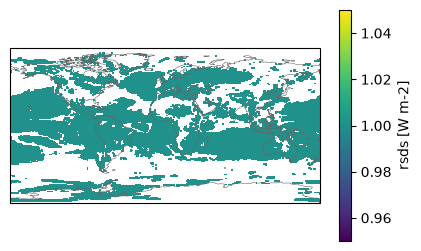

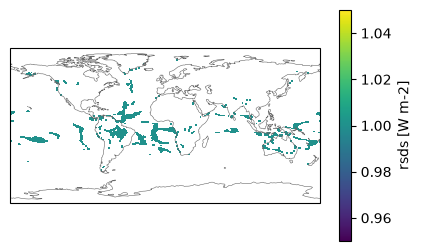

CESM2-WACCM_rsds_historical_r2i1p1f1
CESM2-WACCM_rsds_historical_r3i1p1f1
CESM2-WACCM_rsds_ssp245_003
CESM2-WACCM_rsds_ssp245_008
g6_1p5k_hist
tas


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

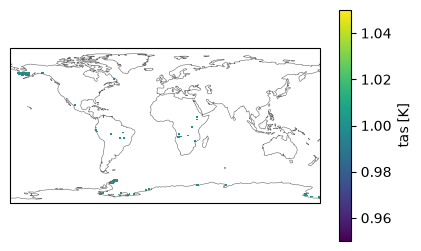

CESM2-WACCM_tas_historical_r2i1p1f1
CESM2-WACCM_tas_historical_r3i1p1f1
CESM2-WACCM_tas_g6_1p5k_002
CESM2-WACCM_tas_g6_1p5k_003
tasmax


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

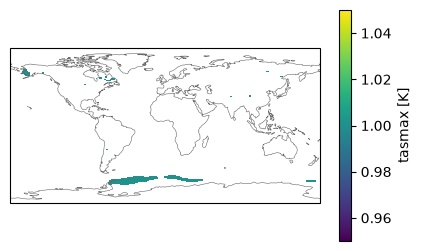

CESM2-WACCM_tasmax_historical_001
CESM2-WACCM_tasmax_g6_1p5k_002
CESM2-WACCM_tasmax_g6_1p5k_003
tasmin


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

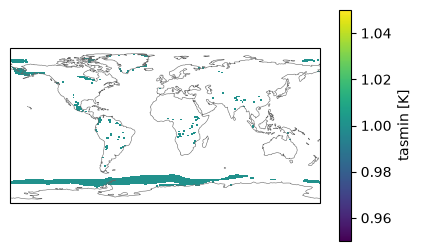

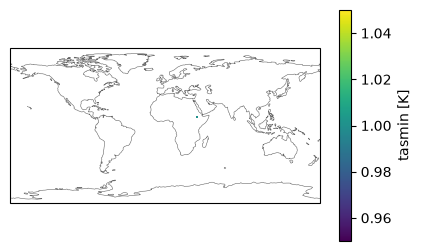

CESM2-WACCM_tasmin_historical_001
CESM2-WACCM_tasmin_g6_1p5k_002
CESM2-WACCM_tasmin_g6_1p5k_003
pr


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

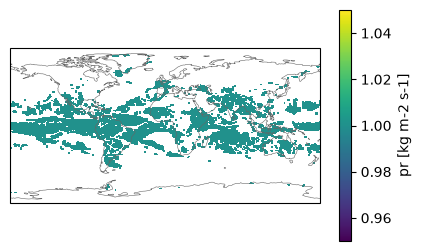

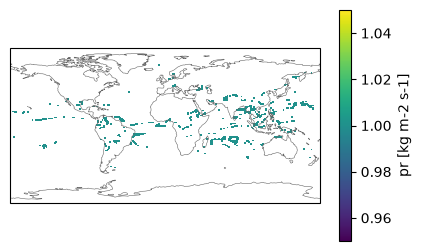

CESM2-WACCM_pr_historical_r2i1p1f1
CESM2-WACCM_pr_historical_r3i1p1f1
CESM2-WACCM_pr_g6_1p5k_002
CESM2-WACCM_pr_g6_1p5k_003
rsds


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

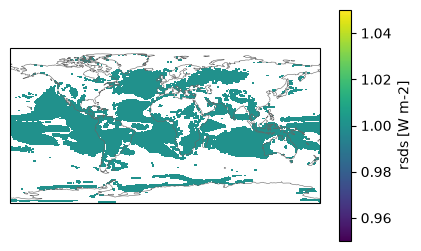

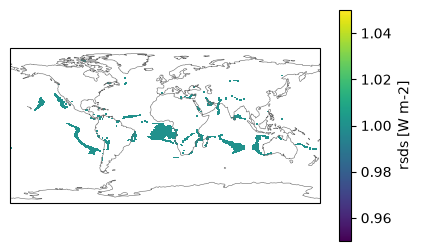

CESM2-WACCM_rsds_historical_r2i1p1f1
CESM2-WACCM_rsds_historical_r3i1p1f1
CESM2-WACCM_rsds_g6_1p5k_002
CESM2-WACCM_rsds_g6_1p5k_003
g6_1p5k_end_g6_1p5k
tas


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

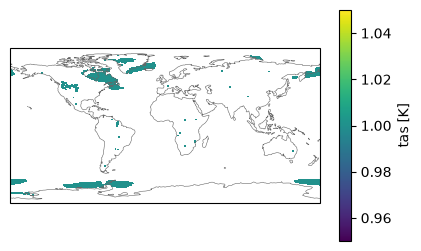

CESM2-WACCM_tas_g6_1p5k_002
CESM2-WACCM_tas_g6_1p5k_003
CESM2-WACCM_tas_g6_1p5k_end_002
tasmax


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

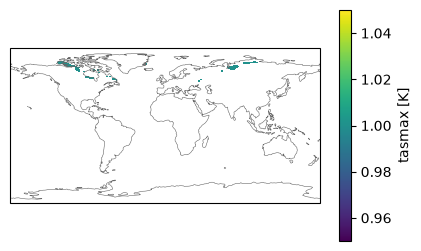

CESM2-WACCM_tasmax_g6_1p5k_002
CESM2-WACCM_tasmax_g6_1p5k_003
CESM2-WACCM_tasmax_g6_1p5k_end_002
tasmin


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

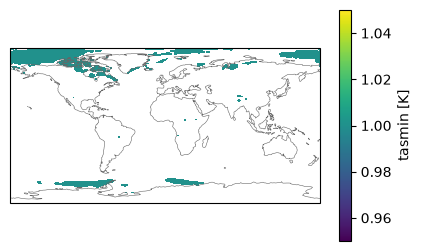

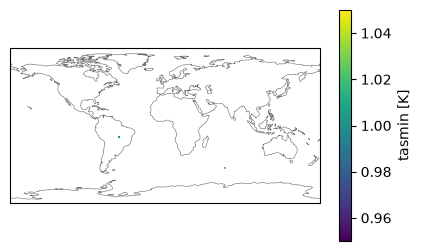

CESM2-WACCM_tasmin_g6_1p5k_002
CESM2-WACCM_tasmin_g6_1p5k_003
CESM2-WACCM_tasmin_g6_1p5k_end_002
pr


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

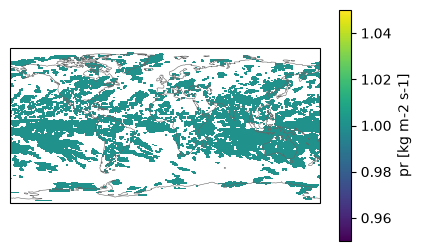

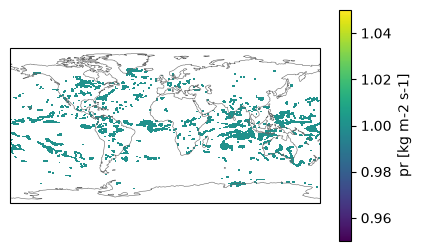

CESM2-WACCM_pr_g6_1p5k_002
CESM2-WACCM_pr_g6_1p5k_003
CESM2-WACCM_pr_g6_1p5k_end_002
rsds


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

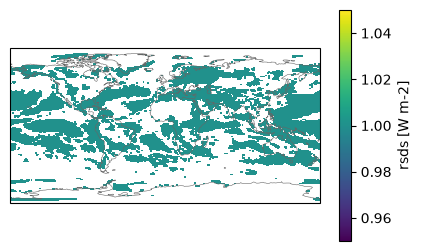

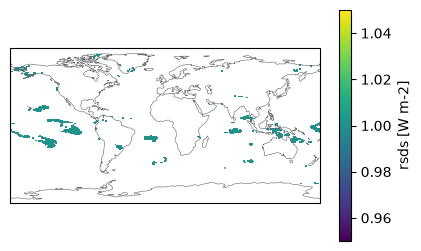

CESM2-WACCM_rsds_g6_1p5k_002
CESM2-WACCM_rsds_g6_1p5k_003
CESM2-WACCM_rsds_g6_1p5k_end_002


In [42]:
plot = True
for key in scenario_comparisons:
    print(key)
    comparison_dict = scenario_comparisons[key]
    scenario1 = comparison_dict["scenario1"]
    scenario2 = comparison_dict["scenario2"]
    scenario1_time_slice = comparison_dict["scenario1_time_slice"]
    scenario2_time_slice = comparison_dict["scenario2_time_slice"]

    for gcm in GCMS:
        for var in VARIABLES:
            print(var)
            # Find tags to use in scenario comparison (all ensemble members for this variable and gcm for the two comparison scenarios)
            tags_scenario1 = tags_np[
                (gcms_np == gcm) * (scenarios_np == scenario1) * (variables_np == var)
            ]
            tags_scenario2 = tags_np[
                (gcms_np == gcm) * (scenarios_np == scenario2) * (variables_np == var)
            ]

            # Calculate distortions
            [delta_raw, delta_raw_pct, delta_ds_coarse, delta_ds_coarse_pct, delta_ds] = (
                calculate_ensemble_mean_deltas(
                    variable=var,
                    tags_scenario1=tags_scenario1,
                    tags_scenario2=tags_scenario2,
                    gcm=gcm,
                    scenario1=scenario1,
                    scenario2=scenario2,
                    scenario1_time_slice=scenario1_time_slice,
                    scenario2_time_slice=scenario2_time_slice,
                )
            )

            distortion_absolute = delta_ds_coarse - delta_raw
            distortion_pct = delta_ds_coarse_pct - delta_raw_pct

            # Flag distortions at coarse scale
            abs_tol = VARIABLE_SETTINGS[var]["abs_tol"]
            pct_tol = VARIABLE_SETTINGS[var]["pct_tol"]
            sign_flip_tol = VARIABLE_SETTINGS[var]["sign_flip"]
            scale = VARIABLE_SETTINGS[var]["scale"]

            trend_distortion_flag = calculate_distortion_flags(
                distortion_absolute=distortion_absolute * scale,
                distortion_pct=distortion_pct,
                tolerance_absolute=abs_tol,
                tolerance_pct=pct_tol,
            )

            flipped_sign_flag = sign_flip_mask(
                delta_ds_coarse * scale, delta_raw * scale, threshold=sign_flip_tol
            )

            # Propagate coarse distortion flags to fine scale
            trend_distortion_flag_fine_frac = interpolate_coarse_to_fine_grid(
                da_coarse_to_regrid=trend_distortion_flag.astype("float32"), da_fine_grid=delta_ds
            )
            trend_distortion_flag_fine = trend_distortion_flag_fine_frac > 0

            flipped_sign_flag_fine_frac = interpolate_coarse_to_fine_grid(
                da_coarse_to_regrid=flipped_sign_flag.astype("float32"), da_fine_grid=delta_ds
            )
            flipped_sign_flag_fine = flipped_sign_flag_fine_frac > 0

            if plot:
                plot_flags(
                    flags=trend_distortion_flag_fine, time_varying=False, separate_low_high=False
                )
                plt.show()
                plt.close()

                plot_flags(
                    flags=flipped_sign_flag_fine, time_varying=False, separate_low_high=False
                )
                plt.show()
                plt.close()

            # Write out flags
            tags_to_flag = np.concat([tags_scenario1, tags_scenario2])
            for tag in tags_to_flag:
                print(tag)
                gcm, var, scenario, ens = parse_tag(tag)
                write_individual_flags(
                    flag_data=trend_distortion_flag_fine,
                    flag_name="trend_distortion_" + scenario1 + "_" + scenario2,
                    gcm=gcm,
                    var=var,
                    scenario=scenario,
                    ens=ens,
                    write_mode="a",
                    flag_dir=FLAG_OUTPUT_DIR,
                    time_varying=False,
                )

                write_individual_flags(
                    flag_data=flipped_sign_flag_fine,
                    flag_name="flipped_sign" + scenario1 + "_" + scenario2,
                    gcm=gcm,
                    var=var,
                    scenario=scenario,
                    ens=ens,
                    write_mode="a",
                    flag_dir=FLAG_OUTPUT_DIR,
                    time_varying=False,
                )

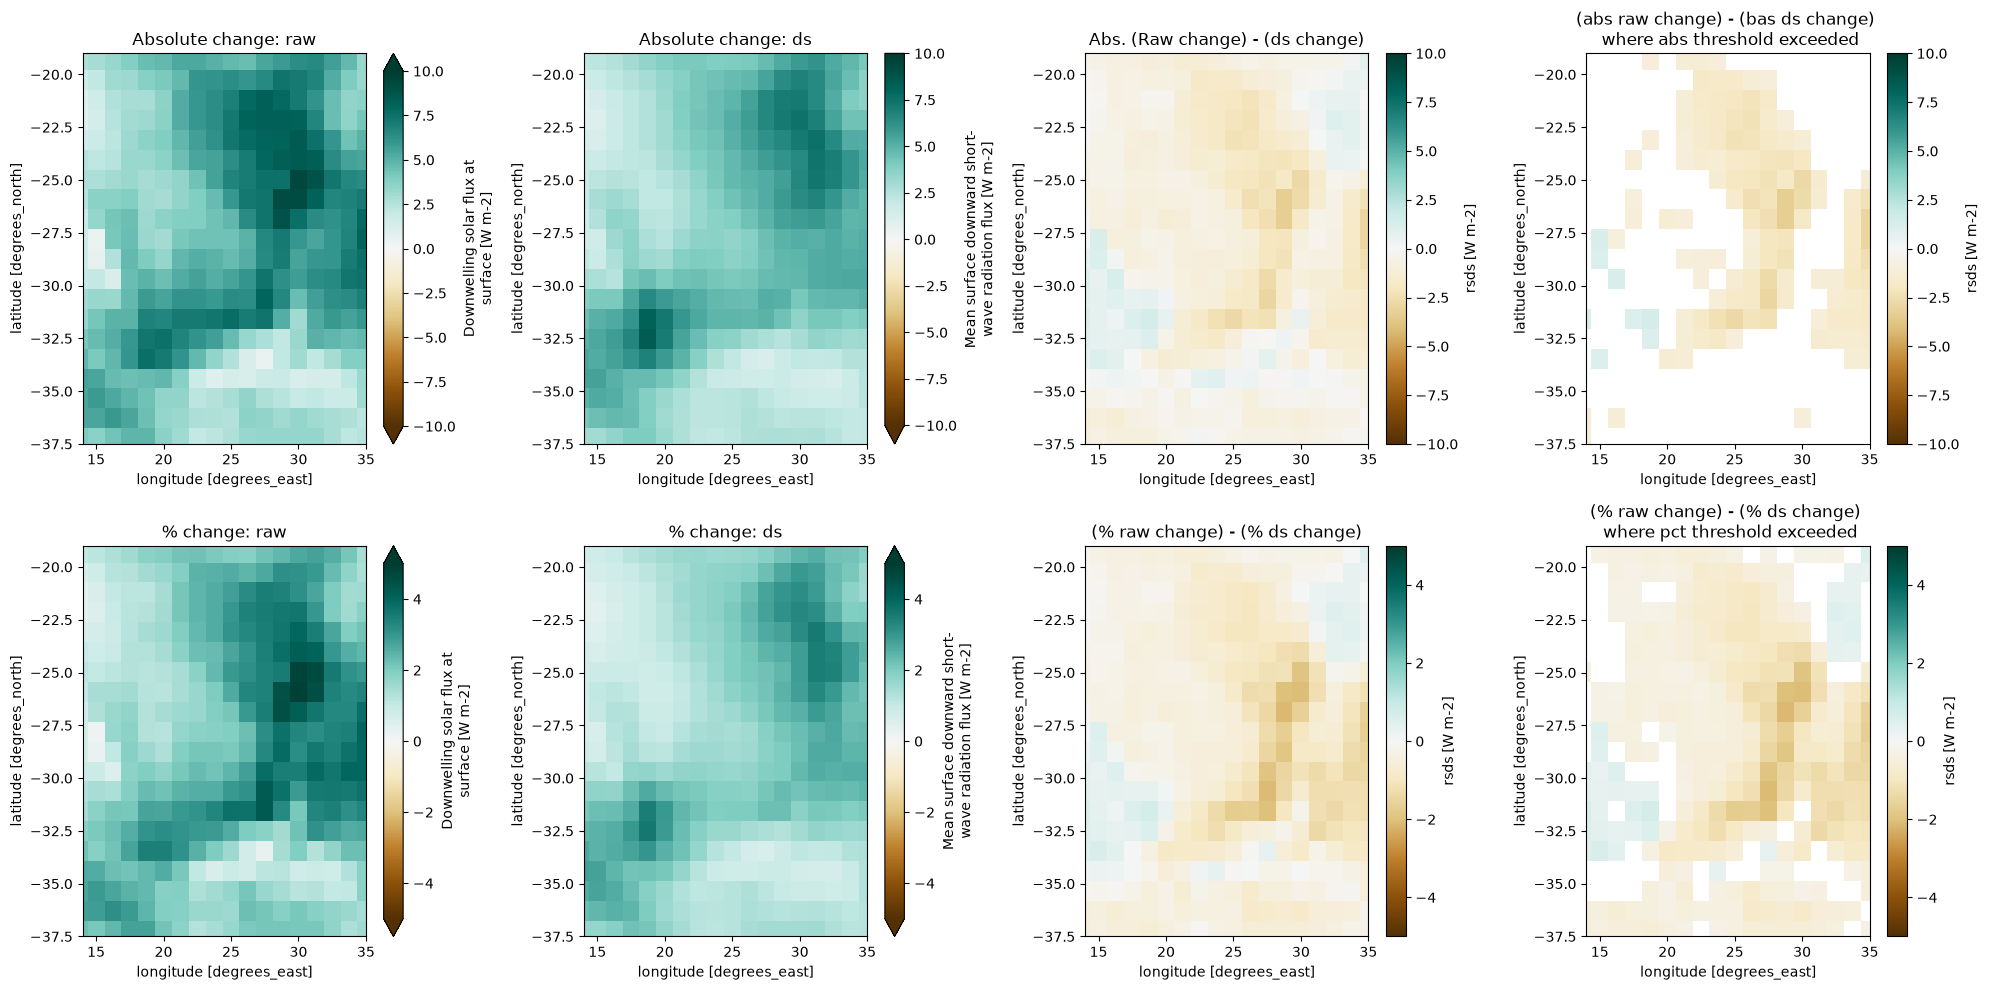

In [43]:
cmap = plt.cm.PuOr
vmax_abs = 5 / scale
vmin_abs = -5 / scale
vmin_pct = -5
vmax_pct = 5

cmap = plt.cm.BrBG
vmax_abs = 10 / scale
vmin_abs = -10 / scale
vmin_pct = -5
vmax_pct = 5


def format_subplot():
    plt.xlim([14, 35])
    plt.ylim([-37.5, -19])


plt.figure(figsize=(20, 10))
plt.subplot(2, 4, 1)
delta_raw.plot(vmin=vmin_abs, vmax=vmax_abs, cmap=cmap)
format_subplot()
plt.title("Absolute change: raw")
plt.subplot(2, 4, 2)
delta_ds_coarse.plot(vmin=vmin_abs, vmax=vmax_abs, cmap=cmap)
format_subplot()
plt.title("Absolute change: ds")
plt.subplot(2, 4, 3)
(delta_ds_coarse - delta_raw).plot(vmin=vmin_abs, vmax=vmax_abs, cmap=cmap)
format_subplot()
plt.title("Abs. (Raw change) - (ds change)")
plt.subplot(2, 4, 4)
delta_delta = delta_ds_coarse - delta_raw
(delta_delta).where(np.abs(delta_delta) > abs_tol / scale).plot(
    vmin=vmin_abs, vmax=vmax_abs, cmap=cmap
)
plt.title("(abs raw change) - (bas ds change) \n where abs threshold exceeded")
format_subplot()

plt.subplot(2, 4, 5)
delta_raw_pct.plot(vmin=vmin_pct, vmax=vmax_pct, cmap=cmap)
plt.title("% change: raw")
format_subplot()
plt.subplot(2, 4, 6)
delta_ds_coarse_pct.plot(vmin=vmin_pct, vmax=vmax_pct, cmap=cmap)
plt.title("% change: ds")
format_subplot()
plt.subplot(2, 4, 7)
(delta_ds_coarse_pct - delta_raw_pct).plot(vmin=vmin_pct, vmax=vmax_pct, cmap=cmap)
plt.title("(% raw change) - (% ds change)")
format_subplot()
plt.subplot(2, 4, 8)
delta_delta = delta_ds_coarse_pct - delta_raw_pct
(delta_delta).where(np.abs(delta_delta) > pct_tol).plot(vmin=vmin_pct, vmax=vmax_pct, cmap=cmap)
plt.title("(% raw change) - (% ds change) \n where pct threshold exceeded")
format_subplot()
plt.tight_layout()

(-37.5, -19.0)

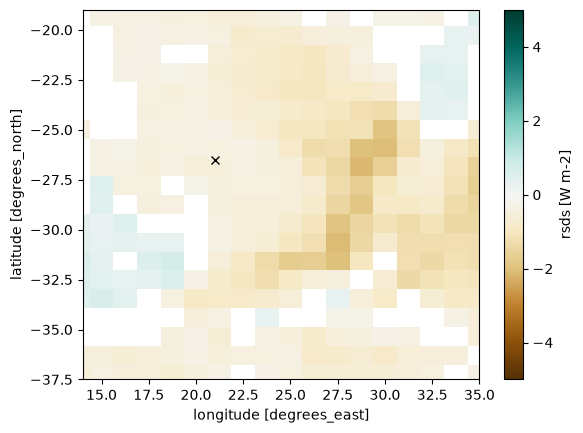

In [44]:
(delta_delta).where(np.abs(delta_delta) > pct_tol).plot(vmin=vmin_pct, vmax=vmax_pct, cmap=cmap)
plt.plot([21], [-26.5], "xk")
plt.xlim([14, 35])
plt.ylim([-37.5, -19])

In [45]:
# Construct data arrays including all relevant ensemble members
das_scenario1 = []
ens_scenario1 = []
for tag in tags_scenario1:
    da = get_data(tag=tag, trees=trees)
    thisgcm, thisvar, thisscenario, thisens = parse_tag(tag)
    das_scenario1.append(da)
    ens_scenario1.append(thisens)

var_scenario1 = xr.concat(das_scenario1, dim=pd.Index(ens_scenario1, name="ensemble_member"))

das_scenario2 = []
ens_scenario2 = []
for tag in tags_scenario2:
    da = get_data(tag=tag, trees=trees)
    thisgcm, thisvar, thisscenario, thisens = parse_tag(tag)
    das_scenario2.append(da)
    ens_scenario2.append(thisens)

var_scenario2 = xr.concat(das_scenario2, dim=pd.Index(ens_scenario2, name="ensemble_member"))

In [46]:
# Take ensemble mean across comparison time periods in raw data
raw_ds = catalog.get(gcm).to_xarray()
raw_scenario1 = raw_ds[scenario1][var]
raw_scenario2 = raw_ds[scenario2][var]

ilat = -26.5
ilon = 21
raw_scenario1_pt = (
    raw_scenario1.sel(lat=ilat, lon=ilon, method="nearest").groupby("time.year").mean().load()
)
raw_scenario2_pt = (
    raw_scenario2.sel(lat=ilat, lon=ilon, method="nearest").groupby("time.year").mean().load()
)

In [47]:
if cluster is not None:
    cluster.shutdown()
else:
    print("no cluster was created (cached run); nothing to shut down")

# D. Read in flags

In [50]:
gcm = "CESM2-WACCM"
var = "rsds"
scenario = "ssp245"
ens = "008"

In [51]:
flag_dir = "s3://carbonplan-scratch/srm/qaqc/flags/" + STORE_SUBSET_ID + "/"

tag = f"{gcm}_{var}_{scenario}_{ens}"
flag_ds = xr.open_dataset(flag_dir + tag + ".zarr", engine="zarr", consolidated=False)

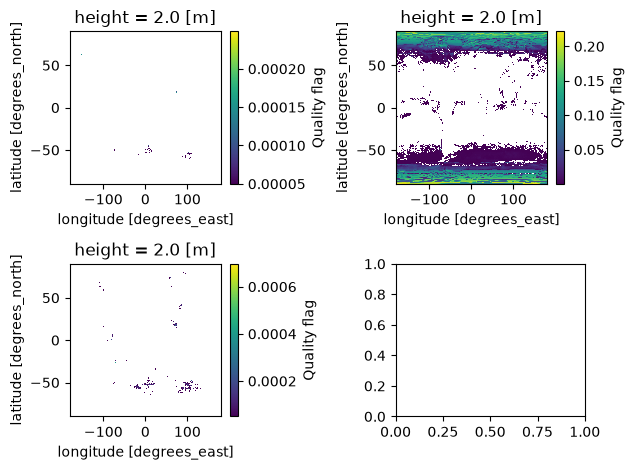

In [52]:
fig, axes = plt.subplots(nrows=2, ncols=2)
flag_frac = flag_ds["outside_global_plausible_range"].mean(dim="time")
flag_frac.where(flag_frac > 0).plot(ax=axes[0, 0])
flag_frac = flag_ds["rsds_max_exceeded"].mean(dim="time")
flag_frac.where(flag_frac > 0).plot(ax=axes[0, 1])
flag_frac = flag_ds["annual_outlier_flag"].mean(dim="time")
flag_frac.where(flag_frac > 0).plot(ax=axes[1, 0])
plt.tight_layout()

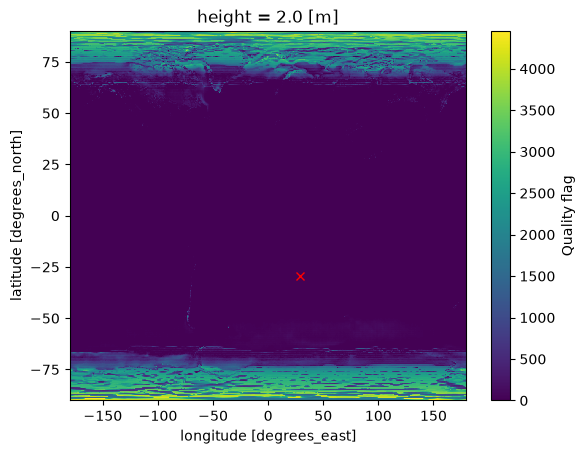

In [53]:
flag_ds["rsds_max_exceeded"].sum(dim="time").plot()
plt.plot([28.5], [-29.6], "xr")

In [54]:
comparison_ds = trees[gcm][scenario][var][ens]
da = comparison_ds[var]

In [55]:
da_raw = catalog.get(gcm).to_xarray()[scenario][var].sel(ensemble_member=ens)

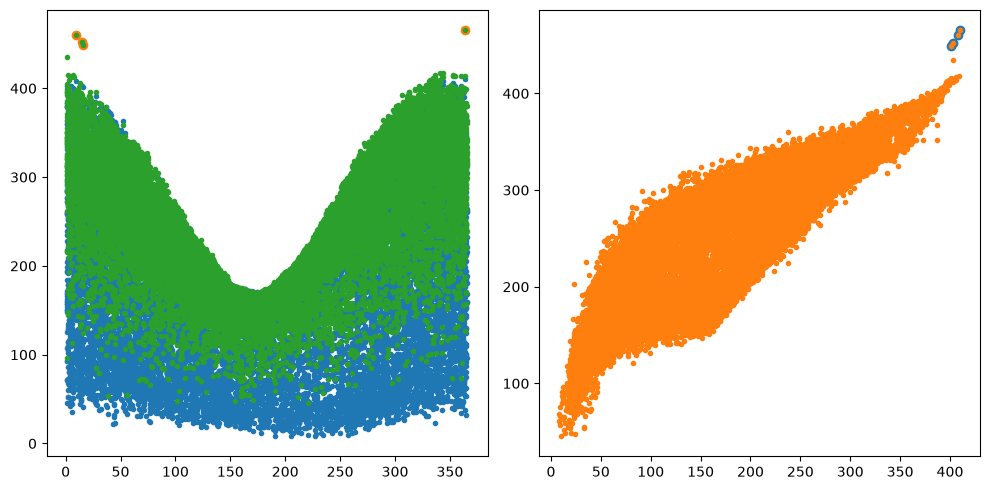

In [56]:
ilat = -29.6
ilon = 28.5
pt_flagged = flag_ds["rsds_max_exceeded"].sel(lat=ilat, lon=ilon, method="nearest")
pt_da = da.sel(lat=ilat, lon=ilon, method="nearest")
pt_da_raw = da_raw.sel(lat=ilat, lon=ilon, method="nearest")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(da_raw["time.dayofyear"], pt_da_raw, ".")
plt.plot(da["time.dayofyear"], pt_da.where(pt_flagged), "o")
plt.plot(da["time.dayofyear"], pt_da, ".")

plt.subplot(1, 2, 2)
plt.plot(pt_da_raw[0 : len(pt_da)], pt_da.where(pt_flagged), "o")
plt.plot(pt_da_raw[0 : len(pt_da)], pt_da, ".")
plt.tight_layout()